# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

### Objective:
#### Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset. 
### Dataset:
#### The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and second column represent exchange rates USD to Australian Dollar.

### Part 1: Data Preparation and Exploration
#### 1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
#### 2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
#### 3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [1]:
## Lets import required libraries..

## Data manipulation..
import pandas as pd
import numpy as np

## Data visualization..
import matplotlib.pyplot as plt
import seaborn as sns

## Ignore warnings.. 
import warnings
warnings.filterwarnings("ignore")

## Display settings..
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
## Now lets load and display the dataset..
df = pd.read_csv("exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
## Basic informations..

## Shape of the dataset..
print("Shape of the Dataset:", df.shape)

## Columns in dataset..
print("\nColumns in Dataset:")
print(df.columns)

## Information..datatypes and non null values.. 
print("\nDataset Information:")
df.info()

Shape of the Dataset: (7588, 2)

Columns in Dataset:
Index(['date', 'Ex_rate'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
## The dataset contains 7588 observations and 2 columns: date and Ex_rate..
## The date column represents the observation date while Ex_rate contains the USD to Australian Dollar exchange rate values used for forecasting..

In [5]:
## Checking the number of missing values..
print("Missing Values:")
print(df.isnull().sum().sum())

## Lets check Duplicate rows..
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
0


In [6]:
## The dataset contains no missing values so no imputation or missing value treatment was required before model building..
## 0 missing values and 0 duplicate rows were found upon checking..

In [7]:
## Lets Convert "Date" column to Datetime..
## Because ARIMA and Exponetial smoothing are time series models and expect the index to represent actual dates/times, not plain text (object)..
df["date"] = pd.to_datetime(df["date"], dayfirst = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7588 non-null   datetime64[ns]
 1   Ex_rate  7588 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 118.7 KB


In [8]:
## "date" column has been successfully converted into datetime64[ns] datatype..

In [9]:
## Now lets set date as index..
df.set_index("date", inplace = True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [10]:
df.info()

## date column is successfully set as index..

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [11]:
## Again Checking  Duplicate rows..
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
2258


In [12]:
## Before converting the date column to the index, the dataset contained 0 duplicate rows..
## After setting date as the index, repeated exchange rate values were detected because only the Ex_rate column remained for duplicate checking..
## These represent valid observations on different dates and were therefore not removed..
## Hence the dataset contains no missing values and no duplicate records..
## Therefore no additional preprocessing was required before building the forecasting models..

In [13]:
## Statistical summary..
print("\nStatistical Summary:")
display(df.describe().T)


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Ex_rate,7588.0,0.776974,0.13662,0.483297,0.701422,0.761377,0.873477,1.102536


In [14]:
## The exchange rate has a mean of approximately 0.777 with a standard deviation of 0.137 indicating moderate variability over time..
## The values range from 0.483 to 1.103 showing noticeable fluctuations in the USD to Australian Dollar exchange rate..

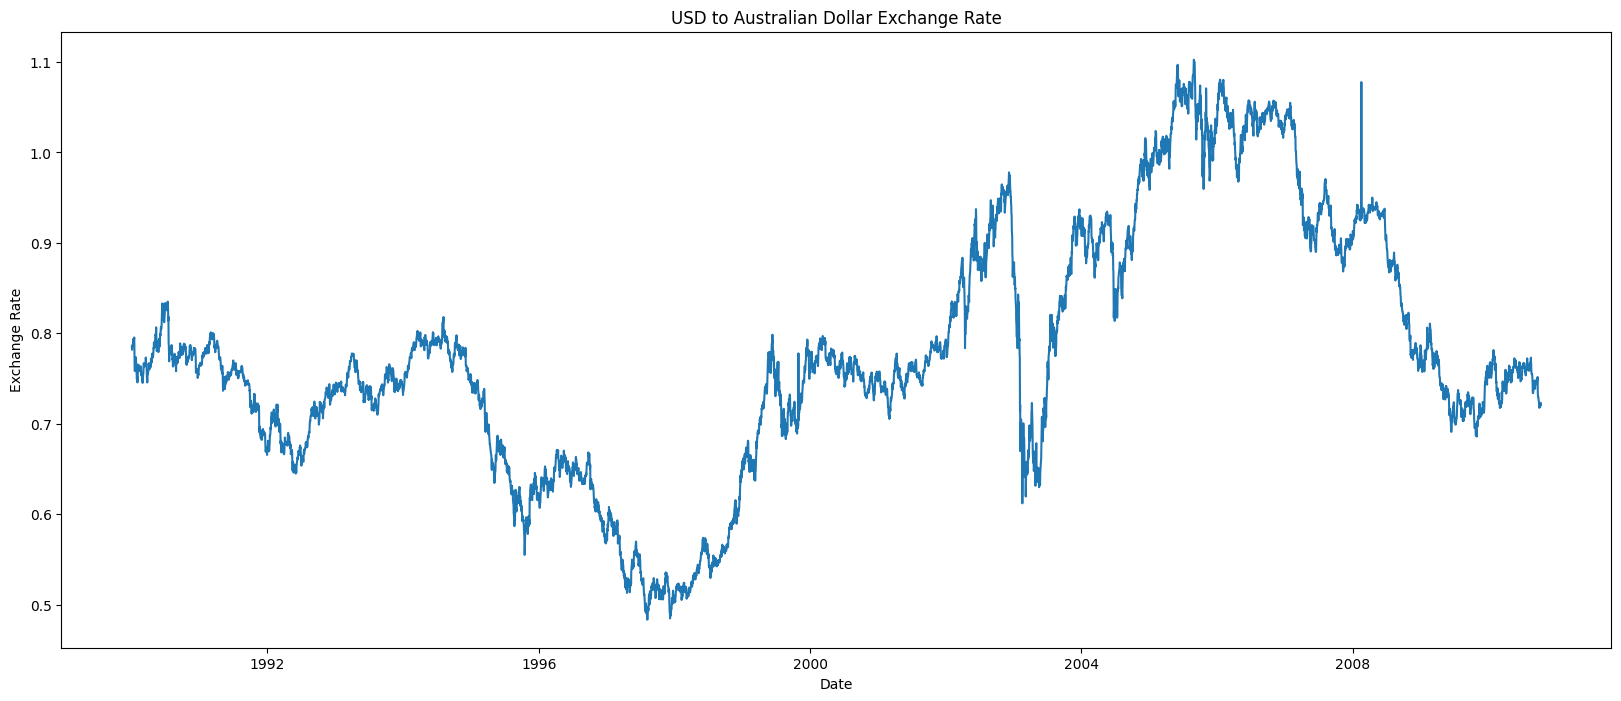

In [15]:
## Now lets create a time series plot..
plt.figure(figsize = (20, 8))
plt.plot(df.index, df["Ex_rate"])
plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

In [16]:
## The time series plot shows that the exchange rate varies considerably over time exhibiting several upward and downward trends.. 
## There is no obvious constant mean suggesting that the series may be non-stationary..
## A few sharp spikes and drops are visible indicating possible anomalies or sudden market movements..
## No clear seasonal pattern is immediately evident from the plot..

### Part 2: Model Building - ARIMA
#### 1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
#### 2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
#### 3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
#### 4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [17]:
## Lets check stationarity (ADF test)..
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Ex_rate"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
1% : -3.4312123140180137
5% : -2.861921078147796
10% : -2.5669728434336108


In [18]:
## The Augmented Dickey-Fuller (ADF) test produced an ADF statistic of -1.665 with a p-value of 0.449, which is greater than the significance level of 0.05..
## Therefore the null hypothesis of a unit root cannot be rejected indicating that the exchange rate series is non-stationary..
## Hence differencing is required before fitting the ARIMA model..

<Figure size 1000x500 with 0 Axes>

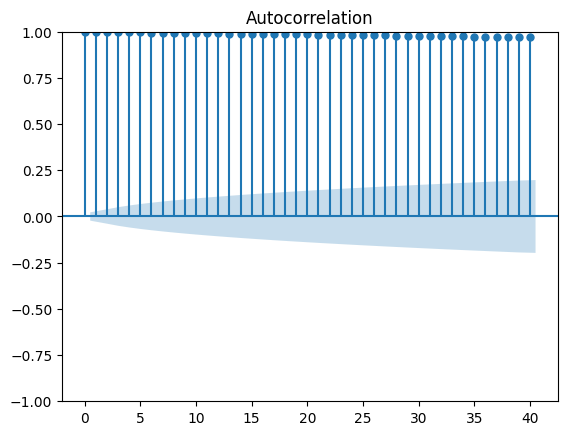

In [19]:
## Lets plot ACF..
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt 

plt.figure(figsize = (10, 5))
plot_acf(df["Ex_rate"], lags = 40)
plt.show()

In [20]:
## The ACF plot shows that autocorrelations remain very high across multiple lags and decay slowly rather than cutting off quickly..
## This behavior is characteristic of a non-stationary time series suggesting that differencing should be applied..

<Figure size 1000x500 with 0 Axes>

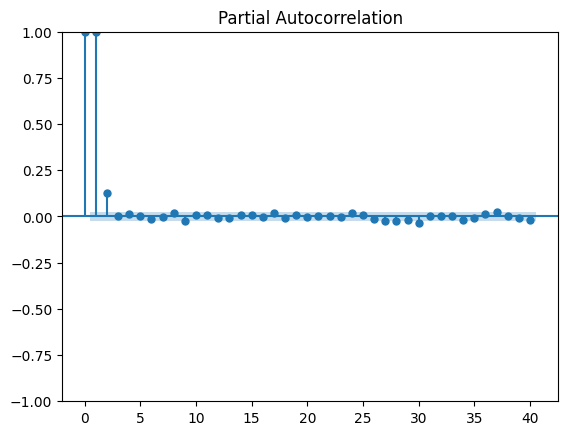

In [21]:
## Now lets plot PACF..
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize = (10, 5))
plot_pacf(df["Ex_rate"], lags = 40)
plt.show()

In [22]:
## The PACF plot shows a strong spike at the first lag followed by values close to zero for subsequent lags..
## This suggests that an initial autoregressive order of p = 1 is a reasonable starting point for the ARIMA model..

## Therefore our initial ARIMA parameters will be..
## p = 1
## d = 1 (because the series is non-stationary)
## q = 1 (a common initial choice when ACF does not show a sharp cutoff)

In [23]:
## Initial ARIMA Parameter Selection..

## Based on the ACF and PACF plots the initial parameters were estimated as (p,d,q) = (1,1,1)..
## To obtain a better model parameter optimization using AIC has to be performed and the optimized model will be used for final forecasting and evaluation..

In [24]:
## Now lets split the data into training and testing parts in 80:20 ratio..
split_index = int(len(df) * 0.8)

train = df["Ex_rate"].iloc[:split_index]
test = df["Ex_rate"].iloc[split_index:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 6070
Test Size: 1518


In [25]:
## The dataset was manually splitted into 80% training data and 20% testing data while preserving the chronological order of observations..
## In time series forecasting random splitting is not appropriate because future values should never be used to predict past values.. 
## Therefore the first 80% of the data was used to train the model and the remaining 20% was reserved to evaluate its forecasting performance on unseen future observations..

In [26]:
from statsmodels.tsa.arima.model import ARIMA

initial_arima_model = ARIMA(train, order = (1, 1, 1))
initial_arima_result = initial_arima_model.fit()
print(initial_arima_result.summary())

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 15 Jun 2026   AIC                         -45432.092
Time:                        00:17:16   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [27]:
## Parameter optimization using AIC.. 
from statsmodels.tsa.arima.model import ARIMA

best_aic = float("inf")
best_order = None
for p in range (4):
    for d in range(2):
        for q in range(4):
            try:
                model = ARIMA(train, order = (p, d, q))
                result = model.fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p, d, q)
            except:
                continue
print("Best Order:", best_order)
print("Best AIC:", best_aic)

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

Best Order: (2, 1, 3)
Best AIC: -45436.21807102956


In [28]:
## Now lets fit ARIMA model on optimized parameters..
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order = (2, 1, 3))
arima_result = arima_model.fit()
print(arima_result.summary())

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(2, 1, 3)   Log Likelihood               22724.109
Date:                Mon, 15 Jun 2026   AIC                         -45436.218
Time:                        00:19:40   BIC                         -45395.952
Sample:                    01-01-1990   HQIC                        -45422.243
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7246      0.094     -7.674      0.000      -0.910      -0.540
ar.L2         -0.7064      0.078     -9.035      0.000      -0.860      -0.553
ma.L1          0.6674      0.094      7.075      0.0

In [29]:
## The ARIMA model forecasts a relatively stable future exchange rate over the test period..
## This behavior indicates that the model expects the series to fluctuate around a similar level rather than showing a strong upward or downward trend..

In [30]:
## Lets forcast on test data now.. 
arima_forecast = arima_result.forecast(steps = len(test))
print(arima_forecast.head())

2006-08-15    1.023781
2006-08-16    1.023976
2006-08-17    1.023633
2006-08-18    1.023743
2006-08-19    1.023906
Freq: D, Name: predicted_mean, dtype: float64


In [31]:
## Prediction on the test period.. 
arima_pred = arima_result.predict(start = len(train), end = len(train) + len(test) -1, typ = "levels")

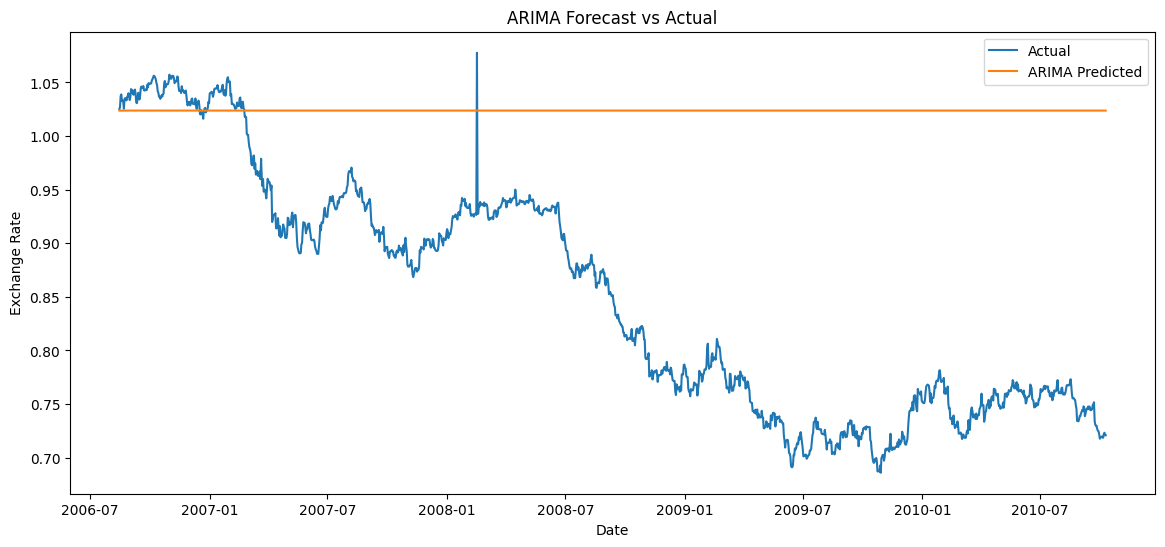

In [32]:
## Now lets plot actual vs forecast(predicted)..
plt.figure(figsize = (14, 6))
plt.plot(test.index, test, label = "Actual")
plt.plot(test.index, arima_pred, label = "ARIMA Predicted")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [33]:
## The graph compares the actual exchange rates with the values forecasted by the ARIMA model..
## The forecast remains relatively stable during the test period suggesting that the model predicts the exchange rate to stay around a similar level..
## Any differences between the actual and forecasted values represent forecasting errors which will be evaluated using error metrics such as MAE, RMSE, and MAPE..

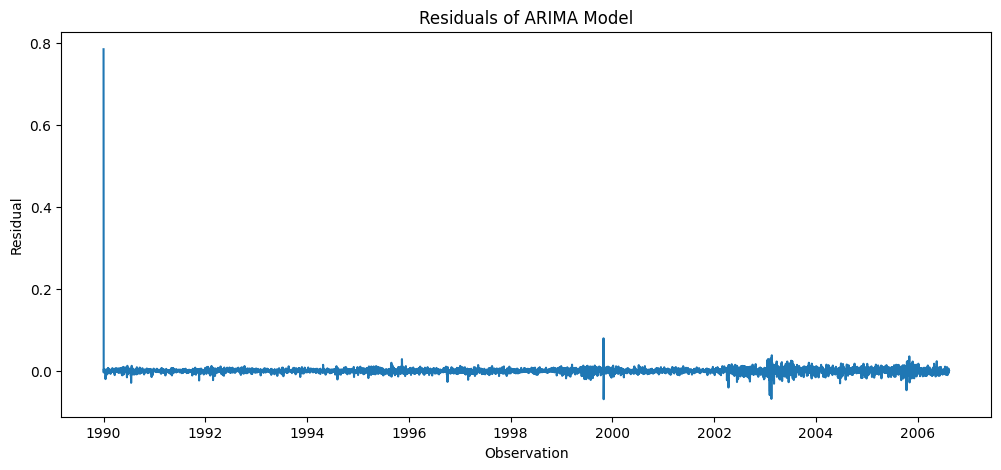

In [34]:
## Residual Plot..
residuals = arima_result.resid
plt.figure(figsize = (12, 5))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.show()

In [35]:
## The residual plot shows the errors made by the ARIMA model..
## Residuals are randomly scattered around zero without any clear pattern it indicates that the model has captured most of the information present in the data..

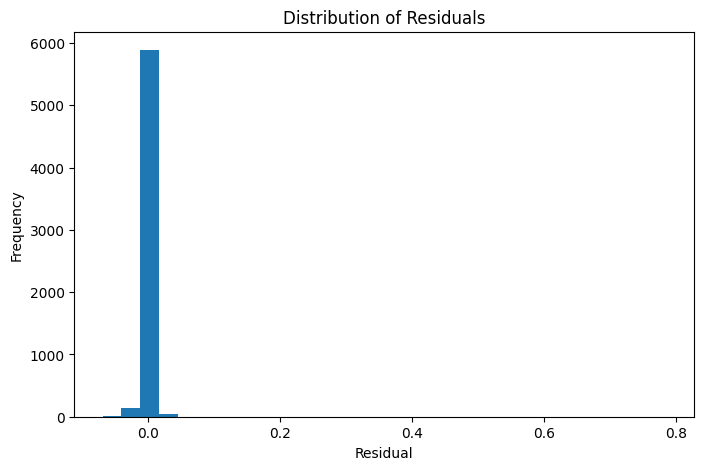

In [36]:
## Residual Distribution ..
plt.figure(figsize = (8, 5))

plt.hist(residuals, bins = 30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [37]:
## The histogram shows the distribution of residuals..
## A distribution centered around zero suggests that the model does not have a strong systematic bias in its predictions..

In [38]:
## Residual Summary..
print(residuals.describe())

count    6070.000000
mean        0.000171
std         0.011593
min        -0.069125
25%        -0.002408
50%         0.000208
75%         0.002709
max         0.785500
dtype: float64


In [39]:
## The summary statistics provide information about the mean, spread and variability of the residuals..
## A mean close to zero indicates that the model is not consistently overestimating or underestimating the exchange rates..

### Part 3: Model Building - Exponential Smoothing
#### 1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).
#### 2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.
#### 3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.

In [40]:
## Since in this timeseries problem we do not have obvious seasonality but has a trend, so we should choose Holt's Linear Trend Model..

from statsmodels.tsa.holtwinters import Holt
holt_model = Holt(train)
holt_fit = holt_model.fit()

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [41]:
## Forecasting..
holt_forecast = holt_fit.forecast(len(test))
print(holt_forecast.head())

2006-08-15    1.023463
2006-08-16    1.023391
2006-08-17    1.023319
2006-08-18    1.023247
2006-08-19    1.023174
Freq: D, dtype: float64


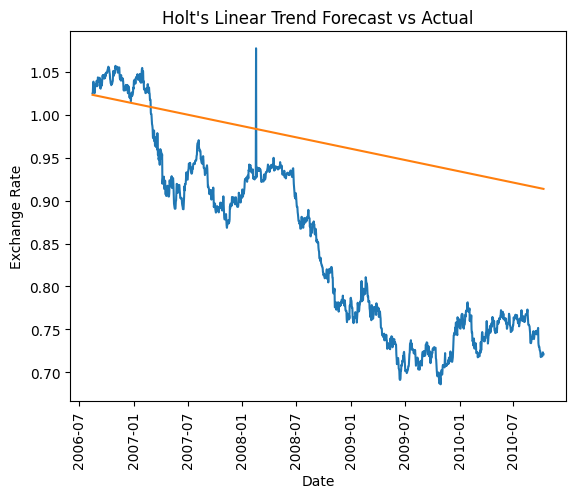

In [42]:
## Plot..
plt.plot(test.index, test, label = "Actual")
plt.plot(test.index, holt_forecast, label = "Holt Forecast")
plt.title("Holt's Linear Trend Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.xticks(rotation = 90)
plt.show()

In [43]:
## The Holt’s Linear Trend model forecasts a gradual decrease in the exchange rate over the test period..
## Unlike the ARIMA forecast, which remains almost constant Holt’s model captures the overall downward trend observed in the actual data.. 
## However since it assumes a linear trend it does not capture all the fluctuations present in the actual exchange rate series..

In [44]:
## Since we optimized ARIMA using AIC, we will also optimize Holt's Linear Trend using AIC which is explcitly mentioned in the assignment..

## Parameter optimization (Holt's Linear)..

## Lets try different options andcompare AIC..
from statsmodels.tsa.holtwinters import ExponentialSmoothing

models = {"Additive Trend": ExponentialSmoothing(train, trend = "add", seasonal = None),
         "Multiplicative Trend": ExponentialSmoothing(train, trend = "mul", seasonal = None)}
best_aic = float("inf")
best_model = None
best_name = None

for name, model in models.items():
    try:
        fit = model.fit(optimized = True)
        print(f"{name} AIC: {fit.aic}")
        if fit.aic < best_aic:
            best_aic = fit.aic
            best_model = fit
            best_name = name
    except:
        pass
print("\nBestModel:", best_name)
print("Best AIC:", best_aic)

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Additive Trend AIC: -62655.663449991895
Multiplicative Trend AIC: -62655.49593401114

BestModel: Additive Trend
Best AIC: -62655.663449991895


In [45]:
## Different Exponential Smoothing models were compared using the AIC value..
## The model with the lowest AIC was selected as the final model because a lower AIC indicates a better balance between model fit and complexity..
## This optimization step helps in choosing a more suitable forecasting model..

In [46]:
## Two Exponential Smoothing models (Additive Trend and Multiplicative Trend) were compared using the AIC value..
## The Additive Trend model had the lower AIC (-62655.66) compared to the Multiplicative Trend model (-62655.50)..
## Since a lower AIC indicates a better model the Additive Trend model was selected for forecasting..

In [47]:
## Now Final Holt's Model..
final_holt_model = ExponentialSmoothing(train, trend = "add", seasonal = None)
final_holt_fit = final_holt_model.fit(optimized = True)

C:\Users\devlok\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [48]:
final_holt_forcast = final_holt_fit.forecast(len(test))
print(final_holt_forcast.head())

2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64


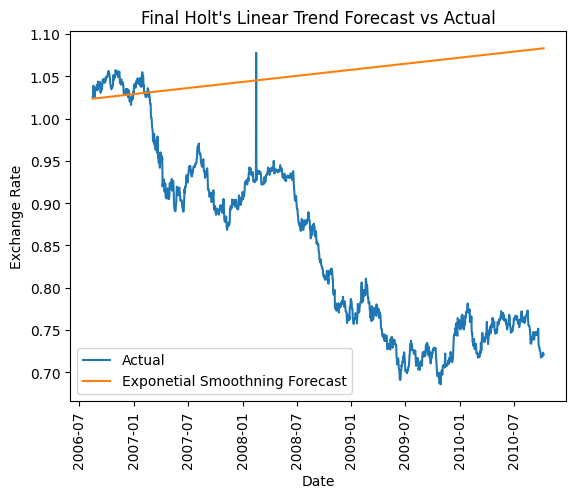

In [49]:
## Final model plotting..
plt.plot(test.index, test, label = "Actual")
plt.plot(test.index, final_holt_forcast, label = "Exponetial Smoothning Forecast")
plt.xticks(rotation = 90)
plt.title("Final Holt's Linear Trend Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

### Part 4: Evaluation and Comparison
#### 1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
#### 2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
#### 3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

In [50]:
## Lets compute MAE, RMSE, and MAPE for ARIMA..
from sklearn.metrics import mean_absolute_error, mean_squared_error

## ARIMA metrics..
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 0.17781717446978423
ARIMA RMSE: 0.20555714569787614
ARIMA MAPE: 22.811637609115124


In [51]:
## Lets compute MAE, RMSE, and MAPE for Exponential Smoothing..
## Final Optimized Model..
## Exponential Smoothning Metrics..

holt_mae = mean_absolute_error(test, final_holt_forcast)
holt_rmse = np.sqrt(mean_squared_error(test, final_holt_forcast))
holt_mape = np.mean(np.abs((test - final_holt_forcast) / test)) * 100

print("Holt MAE:", holt_mae)
print("Holt RMSE:", holt_rmse)
print("Holt MAPE:", holt_mape)

Holt MAE: 0.20659618900700694
Holt RMSE: 0.23910442913206756
Holt MAPE: 26.50866352489013


In [52]:
## The performance of the forecasting models was evaluated using three commonly used error metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE)..
## MAE measures the average absolute difference between the actual and predicted values..
## While RMSE gives greater importance to larger prediction errors..
## MAPE expresses the forecasting error as a percentage making it easier to understand the overall prediction accuracy..
## For all three metrics lower values indicate a better forecasting model because they represent smaller prediction errors..

In [53]:
## Comparison Table.. 
comparison = pd.DataFrame({"Model": ["ARIMA", "Exponential Smoothning"],
                          "MAE": [arima_mae, holt_mae],
                          "RMSE": [arima_rmse, holt_rmse],
                          "MAPE": [arima_mape, holt_mape]})
print(comparison)

                    Model       MAE      RMSE       MAPE
0                   ARIMA  0.177817  0.205557  22.811638
1  Exponential Smoothning  0.206596  0.239104  26.508664


In [54]:
## After evaluating the final models the ARIMA model achieved lower values of MAE, RMSE, and MAPE compared to the final optimized Exponential Smoothing model..
## This indicates that the ARIMA model produced forecasts that were closer to the actual exchange rate values and therefore performed better on the test dataset..
## Based on these evaluation metrics ARIMA proved to be the more accurate forecasting model among the two final models considered for comparison..

#### Additional Observation.. 

In [55]:
## The following evaluation of the initial Holt model is included only for discussion purposes..
## The official model comparison in the assignment is performed using the optimized Exponential Smoothing model..

In [56]:
holt1_mae = mean_absolute_error(test, holt_forecast)
holt1_rmse = np.sqrt(mean_squared_error(test, holt_forecast))
holt1_mape = np.mean(np.abs((test - holt_forecast) / test)) * 100

print("Holt1 MAE:", holt1_mae)
print("Holt1 RMSE:", holt1_rmse)
print("Holt1 MAPE:", holt1_mape)

Holt1 MAE: 0.12457288411821425
Holt1 RMSE: 0.1440378637109814
Holt1 MAPE: 15.964177228270508


In [57]:
## During the analysis an interesting observation was made..
## Before performing parameter optimization an initial Holt’s Linear Trend model was built and evaluated..
## Surprisingly this initial Holt model produced lower MAE, RMSE, and MAPE values than both the ARIMA model and the final optimized Exponential Smoothing model..
## It also appeared to follow the actual downward trend of the exchange rate more closely in the forecast plot..

In [58]:
## However the assignment specifically required parameter optimization for the Exponential Smoothing model..
## Therefore optimization was performed using the AIC criterion and the Additive Trend model with the lowest AIC was selected as the final Exponential Smoothing model..
## Although this optimized model was statistically preferred based on AIC its forecasting errors on the unseen test data turned out to be higher than those of the initial Holt model..

In [59]:
## This observation highlights an important concept in time series forecasting..
## A model with a better AIC value is optimized for fitting the training data while maintaining an appropriate level of complexity but it does not necessarily guarantee the best forecasting performance on future unseen data..
## Therefore it is always important to evaluate forecasting models using practical error metrics such as MAE, RMSE, and MAPE in addition to model selection criteria like AIC..

In [60]:
## The ARIMA model successfully captured the overall behavior of the exchange rate series and achieved lower forecasting errors than the final optimized Exponential Smoothing model..
## Therefore among the two final models required for comparison in this assignment, ARIMA demonstrated better forecasting performance..
## At the same time the analysis also revealed that the initial Holt’s Linear Trend model achieved even lower forecasting errors than both of these models..
## This finding shows that parameter optimization based on AIC may not always produce the model with the best out-of-sample forecasting accuracy and practical evaluation on test data remains an essential step in model selection..

In [61]:
## FINAL CONCLUSION..

## In this assignment historical exchange rate data was analyzed using both ARIMA and Exponential Smoothing techniques..
## The data was successfully loaded, explored, preprocessed, tested for stationarity and used to build forecasting models..
## Forecasts generated by both approaches were evaluated using MAE, RMSE, and MAPE..

## Based on the final comparison required by the assignment, the ARIMA model outperformed the final optimized Exponential Smoothing model because it achieved lower forecasting errors across all evaluation metrics..
## An additional finding from this study was that the initial Holt’s Linear Trend model, before parameter optimization, produced even lower forecasting errors than both final models..

In [62]:
## his demonstrates that while parameter optimization using AIC is a useful model selection technique, it does not always lead to the best forecasting accuracy on unseen data..
## Therefore model selection should consider both statistical criteria and actual forecasting performance to make a well-informed decision..